In [1]:
import pandas as pd
import numpy as np

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# 'pd.read_csv' tells Pandas to open the file
# We store it in a variable called 'df' (short for DataFrame)
df = pd.read_csv('application_train.csv')

# 'df.head()' shows us the first 5 rows, like looking at the top of an Excel sheet
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

# Look at the target variable: 0 = Safe, 1 = Risky
print(df['TARGET'].value_counts())

Total Rows: 307511
Total Columns: 122
TARGET
0    282686
1     24825
Name: count, dtype: int64


In [4]:
df.shape

(307511, 122)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [6]:
# This calculates the percentage of missing values for each column
missing_values = df.isnull().sum() / len(df) * 100
# display(missing_values)
print(missing_values.sort_values(ascending=False).head(5))

COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
dtype: float64


In [7]:
!pip install xgboost

In [8]:
!pip install shap

In [9]:
# We select only the columns that contain numbers
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Fill missing values in those columns with their respective median
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print("Missing numerical values filled!")

Missing numerical values filled!


In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le_count = 0

# Loop through each column
for col in df:
    if df[col].dtype == 'object':
        # If the column has 2 or fewer unique categories (like Gender)
        if len(list(df[col].unique())) <= 2:
            le.fit(df[col])
            df[col] = le.transform(df[col])
            le_count += 1
            
print(f'{le_count} columns were label encoded.')

3 columns were label encoded.


In [11]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,0,M,0,1,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,0,F,0,0,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,1,M,1,1,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,0,F,0,1,0,135000.0,312682.5,29686.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
4,100007,0,0,M,0,1,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
# This converts all remaining text columns into 0s and 1s
df = pd.get_dummies(df)

print(f"New total columns after One-Hot Encoding: {df.shape[1]}")

New total columns after One-Hot Encoding: 243


In [13]:
df.drop(['SK_ID_CURR'], axis=1, inplace=True)

In [14]:
# This finds the correlation of all columns with the 'TARGET' (the default flag)
correlations = df.corr()['TARGET'].sort_values()

print('Most Positive Correlations (Likely to Default):\n', correlations.tail(10))
print('\nMost Negative Correlations (Likely to Repay):\n', correlations.head(10))

Most Positive Correlations (Likely to Default):
 NAME_EDUCATION_TYPE_Secondary / secondary special    0.049824
REG_CITY_NOT_WORK_CITY                               0.050994
DAYS_ID_PUBLISH                                      0.051457
CODE_GENDER_M                                        0.054713
DAYS_LAST_PHONE_CHANGE                               0.055218
NAME_INCOME_TYPE_Working                             0.057481
REGION_RATING_CLIENT                                 0.058899
REGION_RATING_CLIENT_W_CITY                          0.060893
DAYS_BIRTH                                           0.078239
TARGET                                               1.000000
Name: TARGET, dtype: float64

Most Negative Correlations (Likely to Repay):
 EXT_SOURCE_2                           -0.160295
EXT_SOURCE_3                           -0.155892
EXT_SOURCE_1                           -0.098887
NAME_EDUCATION_TYPE_Higher education   -0.056593
CODE_GENDER_F                          -0.054704
NAME_INCO

In [15]:
# Convert days to years and make it positive
df['YEARS_BIRTH'] = df['DAYS_BIRTH'] / -365

# Now let's see the average age of a 'Repayer' vs a 'Defaulter'
age_analysis = df.groupby('TARGET')['YEARS_BIRTH'].mean()
print(age_analysis)

TARGET
0    44.214182
1    40.780351
Name: YEARS_BIRTH, dtype: float64


In [16]:
from sklearn.model_selection import train_test_split

# Drop the Target from the features (X) and keep only the Target in (y)
X = df.drop(columns=['TARGET'])
y = df['TARGET']

# Split: 80% to train the model, 20% to test if it's smart
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

print(f"Training set size: {X_train.shape[1]} columns")
print(f"Testing set size: {X_test.shape[1]} columns")

Training set size: 246008 rows
Testing set size: 61503 rows
Training set size: 242 columns
Testing set size: 242 columns


In [17]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the 'Committee' (100 trees)
# We use n_jobs=-1 to use all your computer's processors
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Teach the model (This might take 1-2 minutes)
print("Training the Random Forest... please wait.")
rf.fit(X_train, y_train)

print("Model Training Complete!")

Training the Random Forest... please wait.
Model Training Complete!


In [18]:
from sklearn.metrics import roc_auc_score

# Predict the probability of default for the test set
predictions = rf.predict_proba(X_test)[:, 1]

# Calculate the AUC score
auc_score = roc_auc_score(y_test, predictions)
print(f"The Model's ROC-AUC Score is: {auc_score:.4f}")

The Model's ROC-AUC Score is: 0.7114


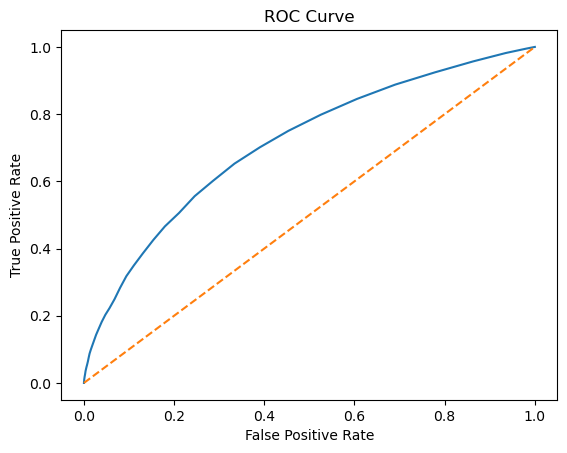

In [19]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, predictions)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')  # random model line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

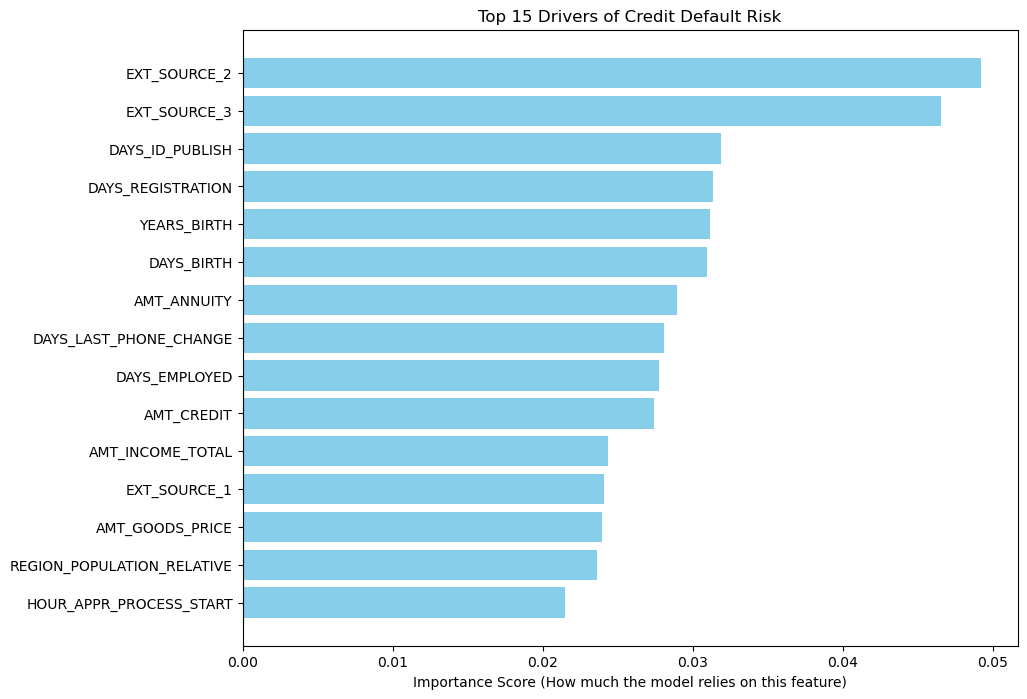

In [20]:
import matplotlib.pyplot as plt

# 1. Get the 'Importance' scores from your trained model
importances = rf.feature_importances_
feature_names = X.columns

# 2. Organize them into a table
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# 3. Sort them so the most important are at the top
top_15 = feature_importance_df.sort_values(by='Importance', ascending=False).head(15)

# 4. Create a professional-looking chart
plt.figure(figsize=(10, 8))
plt.barh(top_15['Feature'], top_15['Importance'], color='skyblue')
plt.gca().invert_yaxis()  # Put the most important at the top
plt.title('Top 15 Drivers of Credit Default Risk')
plt.xlabel('Importance Score (How much the model relies on this feature)')
plt.show()

In [21]:
# You might need to install it if using local Jupyter
!pip install lightgbm

import lightgbm as lgb
print("LightGBM ready for optimization.")

LightGBM ready for optimization.


In [22]:
import re

# 1. This function replaces any non-alphanumeric character with an underscore
X = X.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '_', x))

# 2. Since we changed 'X', we need to re-split the data so 'X_train' has the clean names
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Feature names cleaned! You can now re-run the LightGBM fit cell.")

Feature names cleaned! You can now re-run the LightGBM fit cell.


In [23]:
# 1. Create the LightGBM model with specific 'tuned' settings
lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    colsample_bytree=0.8,
    subsample=0.8,
    n_jobs=-1,
    random_state=42
)

# 2. Train the model (it uses 'Early Stopping' to prevent overfitting)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.454463 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11664
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 231
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[379]	valid_0's auc: 0.760145	valid_0's binary_logloss: 0.245137


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, n_estimators=1000,
               n_jobs=-1, random_state=42, subsample=0.8)

In [24]:
lgb_predictions = lgb_model.predict_proba(X_test)[:, 1]
lgb_auc = roc_auc_score(y_test, lgb_predictions)

print(f"New LightGBM AUC Score: {lgb_auc:.4f}")
print(f"Improvement: {lgb_auc - 0.7114:.4f}")

New LightGBM AUC Score: 0.7601
Improvement: 0.0487


In [25]:
# 'is_unbalance=True' tells LightGBM to automatically weight the 8% of defaulters higher
lgb_model_balanced = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    is_unbalance=True, 
    random_state=42
)

lgb_model_balanced.fit(X_train, y_train)
balanced_auc = roc_auc_score(y_test, lgb_model_balanced.predict_proba(X_test)[:, 1])
print(f"Balanced Model AUC: {balanced_auc:.4f}")

[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.299368 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11664
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 231
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606
Balanced Model AUC: 0.7542


C:\Users\hp\anaconda3\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


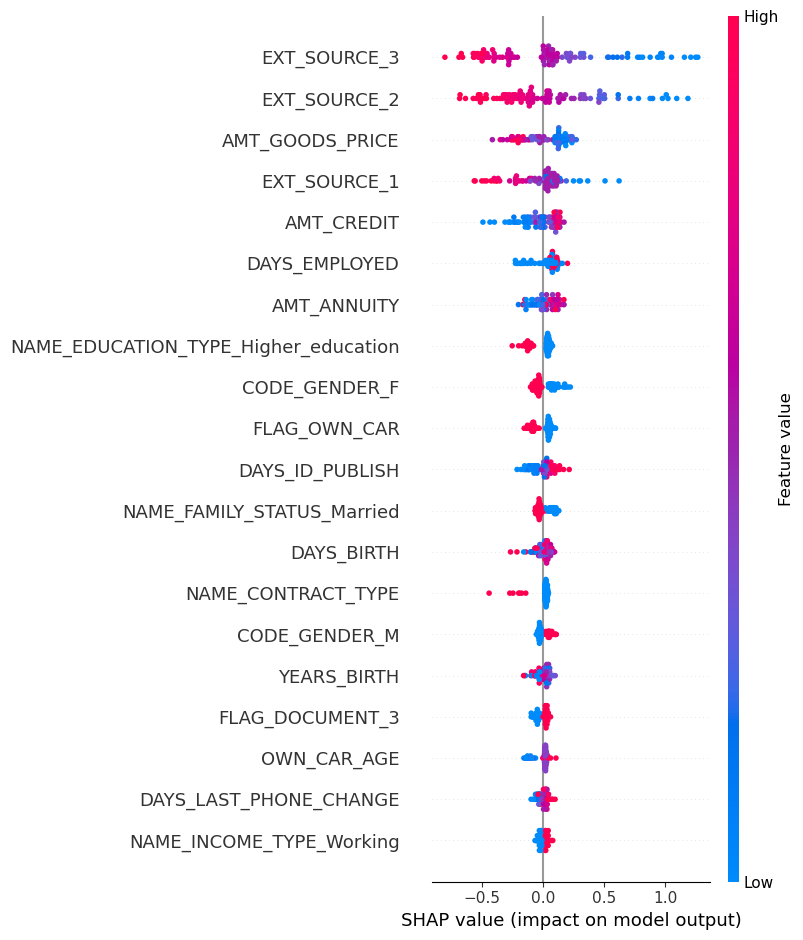

In [26]:
import shap

# 1. Create the explainer
explainer = shap.TreeExplainer(lgb_model)
# 2. Calculate SHAP values for a sample of the test set
shap_values = explainer.shap_values(X_test.iloc[:100, :])

# 3. Create the "Summary Plot"
shap.summary_plot(shap_values, X_test.iloc[:100, :])

In [27]:
import joblib

# Save the model to a file
joblib.dump(lgb_model, 'credit_model.pkl')

# Save the column names so the app knows what inputs to ask for
joblib.dump(X_train.columns.tolist(), 'model_columns.pkl')

print("Model saved as credit_model.pkl!")

Model saved as credit_model.pkl!


In [28]:
# Calculate medians for all columns used in the model
medians = X_train.median()
joblib.dump(medians, 'model_medians.pkl')
print("Medians saved successfully!")

Medians saved successfully!
